# Multi-Class Classification Analysis

This notebook demonstrates different approaches to multi-class classification using synthetic data. We'll explore:
1. One-vs-Rest (OvR) strategy
2. One-vs-One (OvO) strategy
3. Model comparison and visualization

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Set style for better visualizations
sns.set_palette("husl")

In [3]:
# Generate synthetic dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=5,
    n_classes=3,
    random_state=1
)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (800, 10)
Test set shape: (200, 10)


## 1. One-vs-Rest (OvR) Classification

One-vs-Rest Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.75      0.71        75
           1       0.65      0.64      0.65        64
           2       0.70      0.62      0.66        61

    accuracy                           0.68       200
   macro avg       0.68      0.67      0.67       200
weighted avg       0.68      0.68      0.67       200



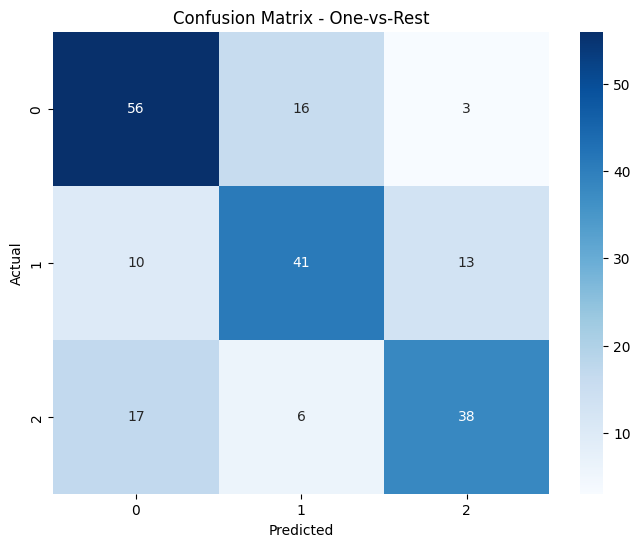

In [4]:
# Initialize and train OvR model
ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr_model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_ovr = ovr_model.predict(X_test)
print("One-vs-Rest Classification Report:")
print(classification_report(y_test, y_pred_ovr))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_ovr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - One-vs-Rest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 2. One-vs-One (OvO) Classification

One-vs-One Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.77      0.74        75
           1       0.73      0.72      0.72        64
           2       0.75      0.69      0.72        61

    accuracy                           0.73       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.73      0.73      0.73       200



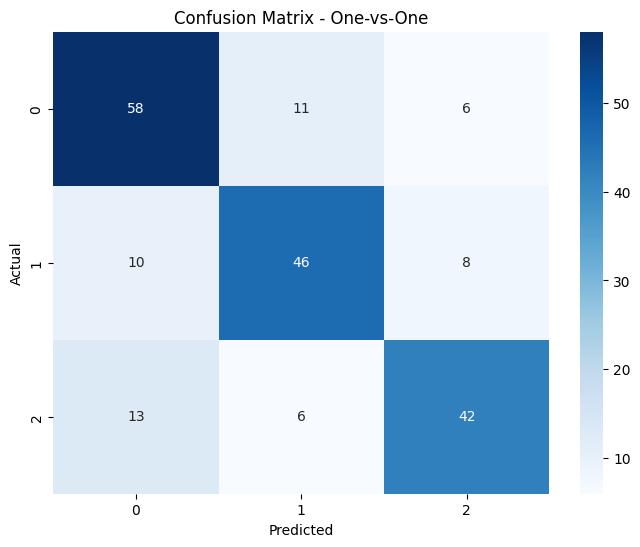

In [5]:
# Initialize and train OvO model
ovo_model = OneVsOneClassifier(LogisticRegression(max_iter=1000))
ovo_model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_ovo = ovo_model.predict(X_test)
print("One-vs-One Classification Report:")
print(classification_report(y_test, y_pred_ovo))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_ovo)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - One-vs-One')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 3. Model Comparison

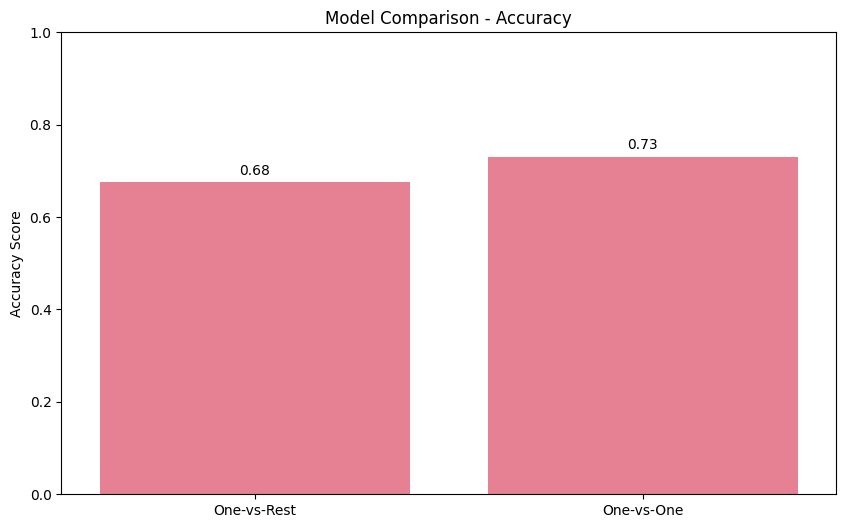


Model Accuracy Scores:
One-vs-Rest: 0.675
One-vs-One: 0.730


In [7]:
# Compare model performances
models = {
    'One-vs-Rest': ovr_model,
    'One-vs-One': ovo_model
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = np.mean(y_pred == y_test)
    results[name] = accuracy

# Plot comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()))
# add values on top of bars
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom')
plt.title('Model Comparison - Accuracy')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.show()

print("\nModel Accuracy Scores:")
for name, accuracy in results.items():
    print(f"{name}: {accuracy:.3f}")